# Assignment 1: Geometry of PCA


### Tasks
1. Generate 2D correlated data
2. Plot the original data
3. Manually choose a direction vector
4. Project data points onto that vector
5. Compare variance before and after projection

### The Big Question I Want to Answer
> **Which direction preserves maximum variance when I project my data onto it?**

---
## Question 1: Generate 2D Correlated Data

I need to generate 200 samples from a 2D distribution where the two features are correlated. I am using a multivariate normal distribution with an off-diagonal covariance matrix to create that correlation.

**Why correlated data?**  
PCA is most useful when features are correlated. This means the data has a preferred direction, and PCA's job is to find that direction. If the data were already axis-aligned, there would be nothing for PCA to discover.

### Answer

In [1]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)          # fix seed for reproducibility

mean = [0, 0]               # data centred at the origin

# Covariance matrix: off-diagonal values = 2 indicate positive correlation
#   [[var(x1),    cov(x1,x2)],
#    [cov(x1,x2), var(x2)   ]]
cov = [[3, 2],
       [2, 2]]

X = np.random.multivariate_normal(mean, cov, 200)   # shape: (200, 2)
print(f"Data shape : {X.shape}")
print(f"Feature means  : {X.mean(axis=0).round(3)}")
print(f"Covariance matrix (sample):\n{np.cov(X.T).round(3)}")


Data shape : (200, 2)
Feature means  : [-0.026  0.012]
Covariance matrix (sample):
[[2.719 1.841]
 [1.841 1.874]]


---
## Question 2: Visualise the Original 2D Data

Before doing anything mathematical, I just want to see what this data looks like. Plotting it first helps me understand the shape of the cloud and where most of the spread is.

### Answer

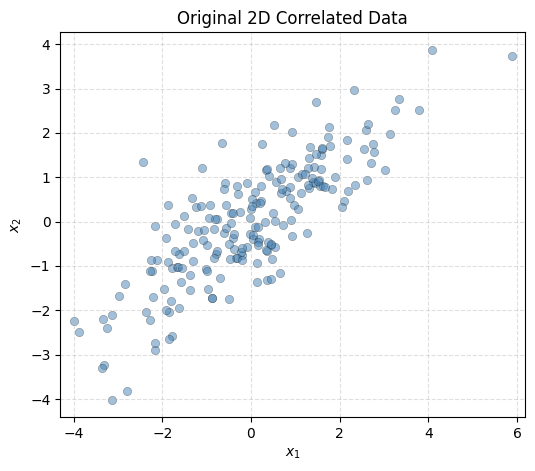

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5,
            color='steelblue', edgecolors='k', linewidths=0.3)

# Equal axes prevent visual distortion of the true spread
plt.axis('equal')
plt.title('Original 2D Correlated Data')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


---
## Question 3: Choose a Direction and Project the Data

Now I will pick a direction (unit vector) manually, not the optimal one, just an arbitrary one, and project all the data points onto it. This lets me see how much spread is preserved versus lost.

I am doing this manually first so that when PCA finds the optimal direction automatically, I will actually understand what it is optimising.


**Step 1 — Pick a unit vector at some angle**

In [3]:
# Choose a direction angle (arbitrary; we will compare its variance to the optimal direction later)
angle = np.radians(70)          # 70° from the positive x-axis

# A unit vector has magnitude 1; [cos θ, sin θ] always satisfies this
v = np.array([np.cos(angle), np.sin(angle)])

print(f"Direction vector v : {v.round(4)}")
print(f"||v||              : {np.linalg.norm(v):.6f}  (must be 1.0)")


Direction vector v : [0.342  0.9397]
||v||              : 1.000000  (must be 1.0)


**Step 2 — Project every point onto v and see what it looks like**

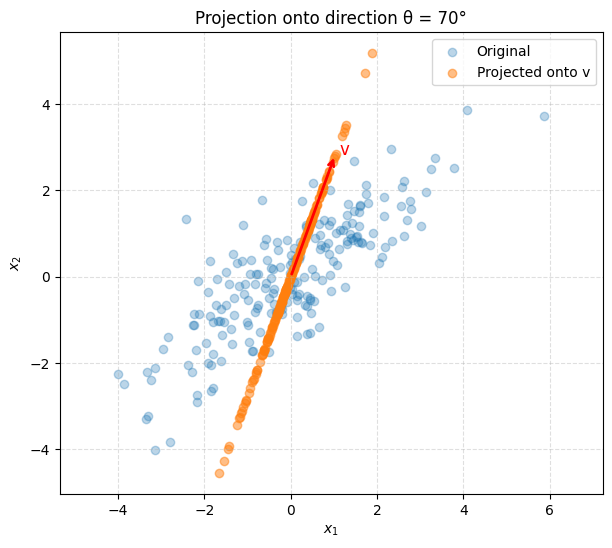

In [4]:
# Scalar projection of each data point onto v
# Result shape: (200,)  — one number per sample (signed distance along v)
projections = X @ v

# Reconstruct 2D coordinates of the projected points so we can plot them
# Each projected point = scalar_projection × v  (lies on the line through origin along v)
X_proj = np.outer(projections, v)   # shape: (200, 2)

# ── Plot original vs projected ────────────────────────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0],      X[:, 1],      alpha=0.3, label='Original')
plt.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, label='Projected onto v')

# Draw the direction vector v as a red arrow for reference
scale = 3
plt.annotate('', xy=(scale * v[0], scale * v[1]), xytext=(0, 0),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.text(scale * v[0] + 0.1, scale * v[1], 'v', color='red', fontsize=12)

plt.legend()
plt.axis('equal')
plt.title('Projection onto direction θ = 70°')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


---
## Question 4: How Much Variance Did I Keep After Projection?

Now I want to measure how much information is lost after projection. I will compute the variance before and after projection and find what percentage was retained.

### Answer

**Step 1 — Variance of the original data**

In [5]:
# np.var computes the mean squared deviation across ALL elements (both features combined)
variance_x = np.var(X)
print(f"Variance of original data X: {variance_x:.4f}")
variance_x


Variance of original data X: 2.2853


2.2853441358169313

**Step 2 — Variance of the projected data (after squishing to 1D)**

In [6]:
# After projection, all points lie on a 1D line embedded in 2D space.
# Variance drops because we discarded the component perpendicular to v.
variance_proj = np.var(X_proj)
print(f"Variance of projected data X_proj: {variance_proj:.4f}")
variance_proj


Variance of projected data X_proj: 1.5703


1.570253523799606

**Step 3 — What percentage of variance did I manage to keep?**

In [7]:
# Ratio tells us what fraction of the original spread is preserved after projection
percent_retention = (variance_proj / variance_x) * 100
print(f"Variance retained : {percent_retention:.2f}%")
print(f"Variance lost     : {100 - percent_retention:.2f}%")
print()
print("Only ~68.7% of the variance is kept because θ=70° is not the optimal direction.")


Variance retained : 68.71%
Variance lost     : 31.29%

Only ~68.7% of the variance is kept because θ=70° is not the optimal direction.


---
## Question 5: So What's the Best Direction?

After trying θ = 70° and only retaining ~68.7% of variance, the natural question is what direction would keep the *most* variance?

The answer is the **first principal component**, which is the eigenvector of the covariance matrix with the largest eigenvalue. I did not figure this out on my own; it is something PCA computes for us. But now that I have seen what projection does to variance, the eigenvector result actually makes sense.

| Concept | What it means |
|---|---|
| PC1 (eigenvector 1) | The direction where the data spreads the most |
| PC2 (eigenvector 2) | The next best direction, perpendicular to PC1 |
| Eigenvalue for PC1 | How much variance is captured along PC1 |
| Eigenvalue for PC2 | How much variance is captured along PC2 |

**What I learned from this:**  
Projecting onto PC1 throws away the least amount of information compared to any other direction. My manual choice of 70° kept only ~68.7% and PCA's PC1 would do better than that.

> PCA finds the eigenvectors of the covariance matrix. The first one points in the direction of maximum variance, and that is why it is the best axis to project onto.